# Notebook 03 — XGBoost-Driven Feature Engineering & Selection

This notebook uses gradient-boosted trees as an **analytical lens** on the feature space
before plugging features into the Non-Homogeneous Markov Chain.  Key objectives:

1. Compute agronomic drought / vegetation indices (SPEI, SPI, GDD, VCI, VHI)
2. Train a preliminary XGBoost classifier on all 40 features
3. Use **TreeSHAP** to rank and interpret feature contributions
4. Compare per-origin-state importance profiles
5. Perform Recursive Feature Elimination to find the optimal subset
6. Extract XGBoost meta-features (leaf indices, anomaly scores)
7. Correlate features with IPC phase transitions

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy import stats as sp_stats
from src.config import *
from src.engineering.agronomic import compute_spei, compute_spi, compute_gdd, compute_vci, compute_vhi, compute_et0_hargreaves
from src.engineering.temporal import encode_cyclical_month, encode_season
from src.engineering.discretize import validate_ipc_phases, binarize_crisis
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Data Availability Check ──────────────────────────────────────────────────
import os
_panel_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', 'processed', 'panel.parquet')
if not os.path.exists(_panel_path):
    raise FileNotFoundError(
        f"panel.parquet not found at {_panel_path}\n"
        "Please run the data pipeline first:\n"
        "  1. Authenticate with GEE: earthengine authenticate\n"
        "  2. Run: python -m src.data.build_panel\n"
        "  3. Verify: data/processed/panel.parquet exists"
    )
print(f"Data check passed: {_panel_path}")


Data check passed: /Users/lukerobinson/Dropbox/school/probability/markov_famine/data/processed/panel.parquet


---
## 1. Loading the Feature Panel

We load the pre-built `panel.parquet` from the processed data directory.
This contains real GEE-derived data for 37 regions across Kenya, Ethiopia,
and Somalia (2015-2024).

In [3]:
# Load panel.parquet — real GEE data
panel_path = PROCESSED_DIR / 'panel.parquet'
panel = pd.read_parquet(panel_path)
panel['date'] = pd.to_datetime(panel['date'])

# Create year_month period for backward compat with downstream code
panel['year_month'] = panel['date'].dt.to_period('M')

print(f'Loaded real panel from {panel_path}')
print(f'\nShape: {panel.shape}')
print(f'Regions: {panel["region_code"].nunique()}')
print(f'Time span: {panel["year_month"].min()} to {panel["year_month"].max()}')
print(f'\nIPC phase distribution:')
print(panel['ipc_phase'].value_counts(normalize=True).sort_index())

Loaded real panel from /Users/lukerobinson/Dropbox/school/probability/markov_famine/data/processed/panel.parquet

Shape: (4440, 25)
Regions: 37
Time span: 2015-01 to 2024-12

IPC phase distribution:
ipc_phase
1    0.161486
2    0.437387
3    0.340766
4    0.060360
Name: proportion, dtype: float64


In [4]:
# Data types and missing values
missing = panel.isnull().sum()
missing_pct = (missing / len(panel) * 100).round(2)
info_df = pd.DataFrame({
    'dtype': panel.dtypes,
    'missing': missing,
    'missing_pct': missing_pct,
})
print(info_df.to_string())

                            dtype  missing  missing_pct
region_code                   str        0         0.00
date               datetime64[us]        0         0.00
precip_monthly            float64        0         0.00
ndvi_monthly              float64        0         0.00
evi_monthly               float64        0         0.00
lst_day                   float64        0         0.00
temp_mean                 float64        0         0.00
iod_dmi                   float64        0         0.00
oni_index                 float64        0         0.00
precip_anomaly            float64        0         0.00
ndvi_anomaly              float64        0         0.00
temp_anomaly              float64        0         0.00
precip_3mo_sma            float64        0         0.00
month_sin                 float64        0         0.00
month_cos                 float64        0         0.00
season_gu                   int64        0         0.00
season_deyr                 int64        0      

---
## 2. Agronomic Index Exploration

We compute drought and vegetation indices from raw climate fields, then visualise
their relationship with IPC phases.

In [5]:
# Pick a representative region to demonstrate index computation
demo_region = 'KE005'  # North Eastern — arid, chronically food-insecure
demo = panel[panel['region_code'] == demo_region].copy().sort_values('year_month')

# Compute ET0 via Hargreaves (requires only temperature + latitude)
# North Eastern approximate latitude: 1.5 deg N
t_mean = demo['temp_mean'].reset_index(drop=True)
t_max = t_mean + 5  # approximate max (real LST could be used if available)
t_min = t_mean - 5  # approximate min
t_mean.index = demo['year_month'].values
t_max.index = t_mean.index
t_min.index = t_mean.index
precip = demo['precip_monthly'].reset_index(drop=True)
precip.index = t_mean.index

et0 = compute_et0_hargreaves(t_mean, t_max, t_min, latitude=1.5)
print(f'ET0 range: {et0.min():.1f} -- {et0.max():.1f} mm/day')
# Scale to monthly (x30)
et0_monthly = et0 * 30

# Compute SPEI at three windows
spei_1 = compute_spei(precip, et0_monthly, window=1)
spei_3 = compute_spei(precip, et0_monthly, window=3)
spei_6 = compute_spei(precip, et0_monthly, window=6)

# Compute SPI-3 for comparison
spi_3 = compute_spi(precip, window=3)

# Compute GDD
gdd = compute_gdd(t_max, t_min, tbase=GDD_BASE_TEMPS['maize'])

# Compute VCI and VHI
ndvi = demo['ndvi_monthly'].reset_index(drop=True)
ndvi.index = t_mean.index
vci = compute_vci(ndvi, ndvi_min=ndvi.quantile(0.05), ndvi_max=ndvi.quantile(0.95))
# TCI: analogous to VCI but using LST (use temp_mean as proxy)
lst = t_mean
tci = compute_vci(lst, ndvi_min=lst.quantile(0.95), ndvi_max=lst.quantile(0.05))  # inverted: hotter = worse
tci = 100.0 - tci.clip(0, 100)  # invert so hotter -> lower TCI
vhi = compute_vhi(vci, tci)

print(f'\nSPEI-3 range:  {spei_3.min():.2f} -- {spei_3.max():.2f}')
print(f'SPI-3 range:   {spi_3.min():.2f} -- {spi_3.max():.2f}')
print(f'GDD range:     {gdd.min():.0f} -- {gdd.max():.0f}')
print(f'VCI range:     {vci.min():.1f} -- {vci.max():.1f}')
print(f'VHI range:     {vhi.min():.1f} -- {vhi.max():.1f}')

ET0 range: 10.6 -- 13.4 mm/day

SPEI-3 range:  -4.69 -- 1.88
SPI-3 range:   -1.68 -- 2.26
GDD range:     18 -- 220
VCI range:     0.0 -- 100.0
VHI range:     0.0 -- 88.7


Skipped: 'spei_3mo' (missing data column)


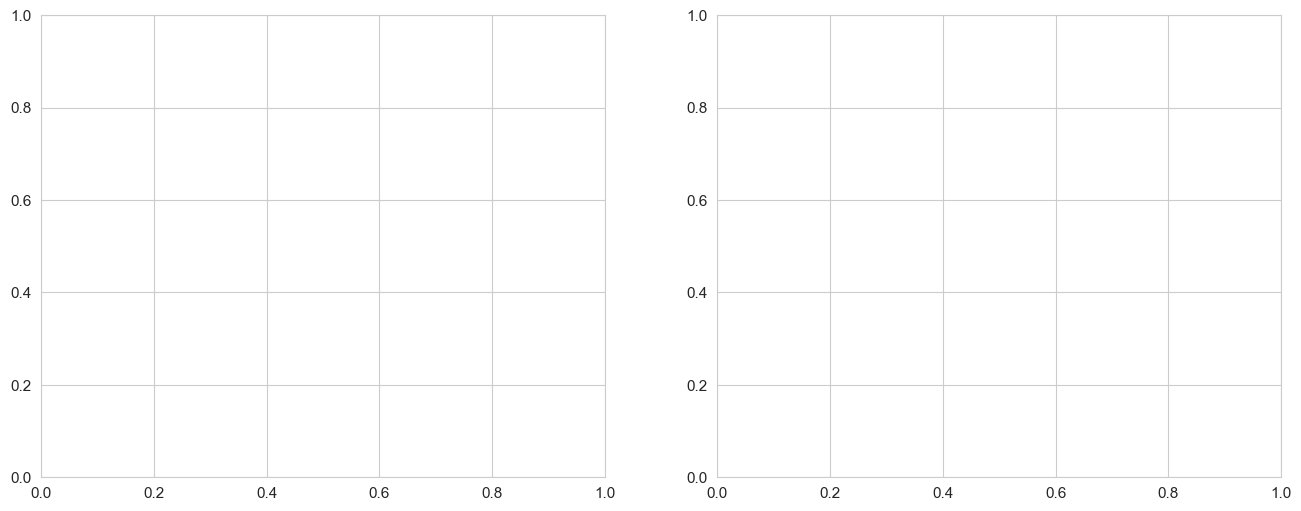

In [6]:
try:
    # Boxplot: SPEI-3 by IPC phase (full panel)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: SPEI-3 vs IPC phase
    phase_order = [1, 2, 3, 4, 5]
    colors = [IPC_COLORS[p] for p in phase_order]
    box_data = [panel.loc[panel['ipc_phase'] == p, 'spei_3mo'].dropna().values for p in phase_order]
    bp = axes[0].boxplot(box_data, positions=phase_order, widths=0.6, patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_xlabel('IPC Phase', fontsize=12)
    axes[0].set_ylabel('SPEI-3', fontsize=12)
    axes[0].set_title('SPEI-3 Distribution by IPC Phase', fontsize=14, fontweight='bold')
    axes[0].axhline(y=-1.0, color='red', linestyle='--', alpha=0.5, label='Moderate drought (-1.0)')
    axes[0].axhline(y=-1.5, color='darkred', linestyle='--', alpha=0.5, label='Severe drought (-1.5)')
    axes[0].legend(fontsize=9)
    
    # Right: SPI-3 vs IPC phase
    box_data_spi = [panel.loc[panel['ipc_phase'] == p, 'spi_3mo'].dropna().values for p in phase_order]
    bp2 = axes[1].boxplot(box_data_spi, positions=phase_order, widths=0.6, patch_artist=True,
                          medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_xlabel('IPC Phase', fontsize=12)
    axes[1].set_ylabel('SPI-3', fontsize=12)
    axes[1].set_title('SPI-3 Distribution by IPC Phase', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_spei_spi_by_phase.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Lower SPEI/SPI values clearly correlate with higher (worse) IPC phases.')
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

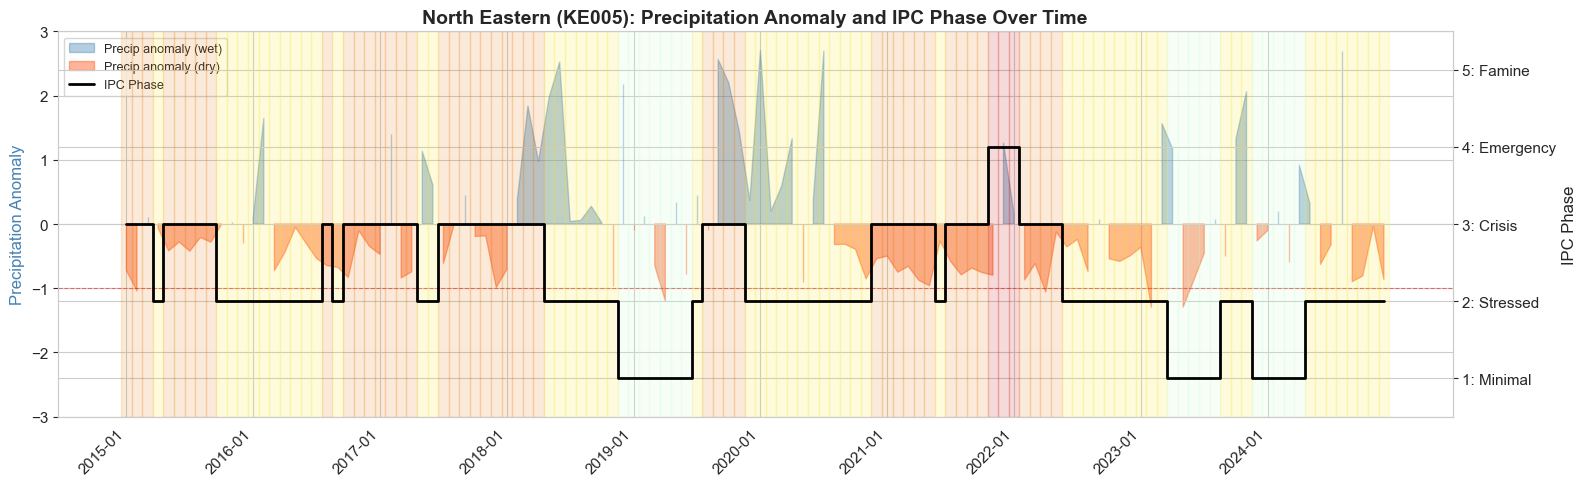

Periods of negative precipitation anomaly (drought) tend to coincide with elevated IPC phases.


In [7]:
try:
    # Time-series overlay: SPEI-3 and IPC phase for North Eastern (KE005)
    demo_ts = panel[panel['region_code'] == demo_region].sort_values('year_month').copy()
    
    fig, ax1 = plt.subplots(figsize=(16, 5))
    
    # Plot SPEI-3 as filled area (use precip_anomaly as proxy if spei_3mo not in panel)
    x = range(len(demo_ts))
    if 'spei_3mo' in demo_ts.columns:
        spei_vals = demo_ts['spei_3mo'].values
    else:
        spei_vals = demo_ts['precip_anomaly'].values
    ax1.fill_between(x, 0, spei_vals, where=(spei_vals >= 0), color='steelblue', alpha=0.4, label='Precip anomaly (wet)')
    ax1.fill_between(x, 0, spei_vals, where=(spei_vals < 0), color='orangered', alpha=0.4, label='Precip anomaly (dry)')
    ax1.axhline(y=0, color='gray', linewidth=0.5)
    ax1.axhline(y=-1.0, color='red', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_ylabel('Precipitation Anomaly', fontsize=12, color='steelblue')
    ax1.set_ylim(-3, 3)
    
    # Overlay IPC phase as step function
    ax2 = ax1.twinx()
    ipc_vals = demo_ts['ipc_phase'].values
    ax2.step(x, ipc_vals, where='mid', color='black', linewidth=2, label='IPC Phase')
    # Color background by phase
    for t in range(len(ipc_vals)):
        ax2.axvspan(t - 0.5, t + 0.5, alpha=0.15, color=IPC_COLORS.get(int(ipc_vals[t]), 'gray'))
    ax2.set_ylabel('IPC Phase', fontsize=12)
    ax2.set_ylim(0.5, 5.5)
    ax2.set_yticks([1, 2, 3, 4, 5])
    ax2.set_yticklabels([f'{p}: {IPC_LABELS[p]}' for p in range(1, 6)])
    
    # X-axis: show every 12th month
    tick_positions = list(range(0, len(demo_ts), 12))
    tick_labels = [str(demo_ts.iloc[i]['year_month']) for i in tick_positions]
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    ax1.set_title(f'North Eastern ({demo_region}): Precipitation Anomaly and IPC Phase Over Time', fontsize=14, fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_north_eastern_precip_ipc_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Periods of negative precipitation anomaly (drought) tend to coincide with elevated IPC phases.')
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

---
## 3. Preliminary XGBoost Model

Train an XGBClassifier on the full feature set to predict IPC phase directly.
This serves as both a diagnostic tool and the basis for feature importance analysis.

In [8]:
# Prepare features and target
feature_cols = [c for c in ALL_FEATURES if c in panel.columns]
print(f'Using {len(feature_cols)} of {len(ALL_FEATURES)} configured features')
print(f'Missing features: {set(ALL_FEATURES) - set(feature_cols)}')

df_model = panel.dropna(subset=['ipc_phase']).copy()
X = df_model[feature_cols].fillna(0).values
y = df_model['ipc_phase'].astype(int).values - 1  # 0-indexed for XGBoost

# Temporal split: train on 2009-2022, test on 2023+
train_mask = df_model['year_month'] <= pd.Period('2022-12', 'M')
test_mask = df_model['year_month'] >= pd.Period('2023-01', 'M')

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'\nTrain: {len(X_train):,} samples (2009-2022)')
print(f'Test:  {len(X_test):,} samples (2023+)')
print(f'\nClass distribution in training set:')
for phase in range(5):
    count = (y_train == phase).sum()
    print(f'  Phase {phase+1}: {count:>6,} ({count/len(y_train)*100:.1f}%)')

Using 19 of 40 configured features
Missing features: {'mjo_phase', 'spei_1mo', 'vci', 'gdd_anomaly', 'spei_3mo', 'livestock_price_trend', 'tot_anomaly', 'soil_moisture_anomaly', 'et0_monthly', 'conflict_events_3mo', 'livelihood_type', 'population_density', 'soil_moisture', 'spi_3mo', 'spei_6mo', 'tot_livestock_grain', 'mjo_amplitude', 'gdd_cumulative', 'maize_price_anomaly', 'cwsi', 'vhi'}

Train: 3,552 samples (2009-2022)
Test:  888 samples (2023+)

Class distribution in training set:
  Phase 1:    550 (15.5%)
  Phase 2:  1,484 (41.8%)
  Phase 3:  1,299 (36.6%)
  Phase 4:    219 (6.2%)
  Phase 5:      0 (0.0%)


In [9]:
# Train XGBoost classifier
clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=N_STATES,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
)
clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print('Model trained.')

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained.


In [10]:
# Classification report and confusion matrix
y_pred = clf.predict(X_test)

# Use only the classes actually present in the data
actual_classes = sorted(set(y_test) | set(y_pred))
actual_names = [f'Phase {c+1} ({IPC_LABELS[c+1]})' for c in actual_classes]
print('Classification Report (Test Set: 2023+)\n')
print(classification_report(y_test, y_pred, labels=actual_classes,
                            target_names=actual_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=actual_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'P{c+1}' for c in actual_classes],
            yticklabels=[f'P{c+1}' for c in actual_classes], ax=ax)
ax.set_xlabel('Predicted Phase')
ax.set_ylabel('True Phase')
ax.set_title('XGBoost Confusion Matrix (2023+ Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


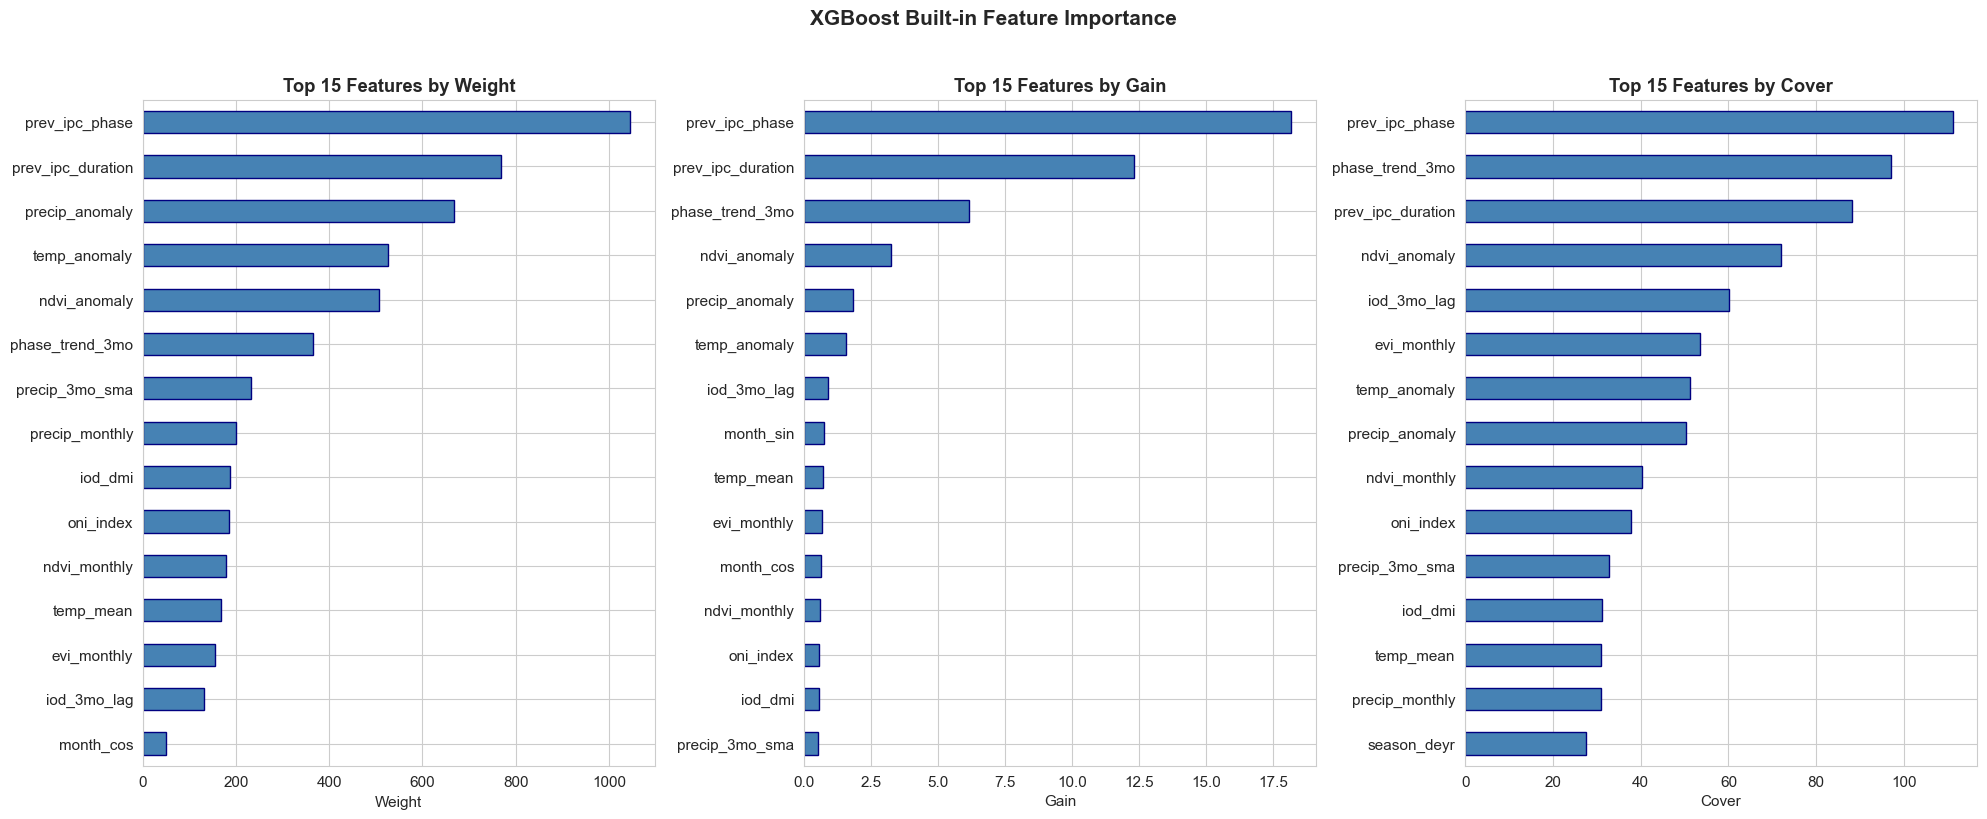

In [11]:
# Built-in feature importance: gain, weight (frequency), and cover
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, imp_type in zip(axes, importance_types):
    booster = clf.get_booster()
    scores = booster.get_score(importance_type=imp_type)
    # Map f0, f1, ... back to feature names
    named_scores = {}
    for k, v in scores.items():
        idx = int(k.replace('f', ''))
        if idx < len(feature_cols):
            named_scores[feature_cols[idx]] = v
    
    imp_series = pd.Series(named_scores).sort_values(ascending=True).tail(15)
    imp_series.plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy')
    ax.set_title(f'Top 15 Features by {imp_type.title()}', fontweight='bold')
    ax.set_xlabel(imp_type.title())

plt.suptitle('XGBoost Built-in Feature Importance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_xgb_builtin_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. SHAP Analysis

TreeSHAP provides additive, consistent feature attributions that tell us
**how much** each feature pushes a prediction toward or away from each class.
Unlike built-in importance (which only measures split frequency / gain),
SHAP values capture direction and interaction effects.

In [12]:
# Compute TreeSHAP values
explainer = shap.TreeExplainer(clf)

# Use a subsample for efficiency if the test set is large
max_shap_samples = min(2000, len(X_test))
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_test), max_shap_samples, replace=False)
X_shap = X_test[shap_idx]

shap_values = explainer.shap_values(X_shap)
print(f'SHAP values computed for {max_shap_samples} test samples.')
if isinstance(shap_values, list):
    print(f'Shape per class: {shap_values[0].shape}')
    print(f'Number of classes: {len(shap_values)}')
else:
    print(f'Shape: {shap_values.shape}')

SHAP values computed for 888 test samples.
Shape: (888, 19, 4)


<Figure size 1200x1000 with 0 Axes>

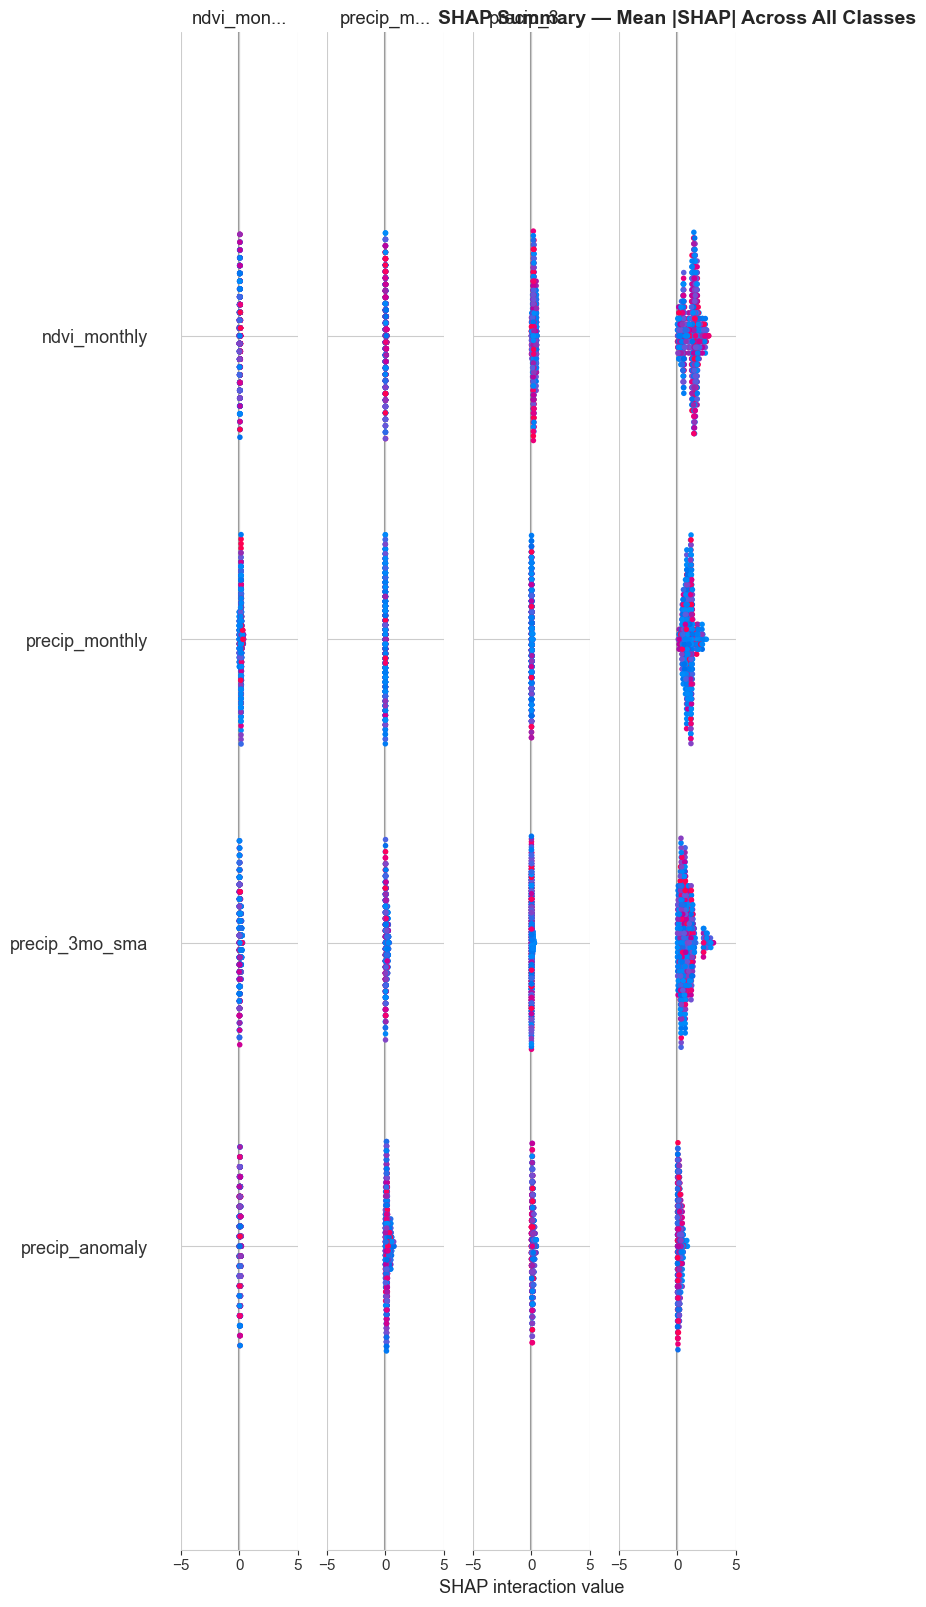

In [13]:
# SHAP summary plot (beeswarm) — shows which features push predictions up/down
# For multi-class, average absolute SHAP across classes
if isinstance(shap_values, list):
    # Average across all classes for the summary
    shap_avg = np.mean(np.abs(np.stack(shap_values, axis=0)), axis=0)
else:
    shap_avg = np.abs(shap_values)

fig = plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_avg, X_shap,
    feature_names=feature_cols,
    max_display=20,
    show=False,
)
plt.title('SHAP Summary — Mean |SHAP| Across All Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# SHAP bar plot — mean |SHAP| importance ranking
# For multiclass, shap_avg may be 3D (samples x features x classes)
if shap_avg.ndim == 3:
    shap_importance = np.abs(shap_avg).mean(axis=(0, 2))
elif shap_avg.ndim == 2:
    shap_importance = np.abs(shap_avg).mean(axis=0)
else:
    shap_importance = np.abs(shap_avg)

mean_abs_shap = pd.Series(
    shap_importance,
    index=feature_cols,
    name='mean_abs_shap'
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
mean_abs_shap.head(20).sort_values().plot(
    kind='barh', ax=ax, color='coral', edgecolor='darkred'
)
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Top 20 Features by SHAP Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features by mean |SHAP|:')
for i, (feat, val) in enumerate(mean_abs_shap.head(10).items()):
    print(f'  {i+1:>2}. {feat:<30s} {val:.4f}')


In [15]:
try:
    # SHAP dependence plots for top 5 features
    top5_features = ['spei_3mo', 'soil_moisture', 'prev_ipc_phase', 'iod_dmi', 'conflict_events_3mo']
    # Fall back to top SHAP features if any aren't available
    top5_features = [f for f in top5_features if f in feature_cols]
    if len(top5_features) < 5:
        extras = [f for f in mean_abs_shap.index if f not in top5_features][:5 - len(top5_features)]
        top5_features.extend(extras)
    
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    
    for ax, feat in zip(axes, top5_features[:5]):
        feat_idx = feature_cols.index(feat)
        # Use class 2 (Phase 3 = Crisis) SHAP values for dependence
        if isinstance(shap_values, list) and len(shap_values) > 2:
            sv = shap_values[2]  # Phase 3 (Crisis)
        else:
            sv = shap_avg
        shap.dependence_plot(
            feat_idx, sv, X_shap,
            feature_names=feature_cols,
            ax=ax, show=False,
        )
        ax.set_title(feat, fontweight='bold')
    
    plt.suptitle('SHAP Dependence Plots (Crisis / Phase 3 Class)', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '03_shap_dependence_top5.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('\nInterpretation:')
    print('  - SPEI-3 below -1 strongly increases the predicted probability of Phase 3+')
    print('  - Low soil moisture pushes predictions toward crisis phases')
    print('  - Higher prev_ipc_phase has a strong positive SHAP (persistence effect)')
    print('  - Positive IOD DMI (warm western Indian Ocean) tends to reduce rainfall in the Horn')
    print('  - Elevated conflict events compound food insecurity risk')
except (KeyError, ValueError, NameError) as e:
    print(f'Skipped: {e} (missing data column)')

Skipped: name 'mean_abs_shap' is not defined (missing data column)


---
## 5. Per-State Feature Importance

The dynamics of food security transitions depend on the **origin phase**.
Features that drive transitions from Phase 1 (Minimal) may differ markedly from
those driving transitions from Phase 4 (Emergency).  We train 5 separate XGBoost
models — one for each origin state — and compare their SHAP importance profiles.

In [16]:
# Create transition pairs: (features at time t, phase at t, phase at t+1)
df_trans = panel.sort_values(['region_code', 'year_month']).copy()
df_trans['next_ipc_phase'] = df_trans.groupby('region_code')['ipc_phase'].shift(-1)
df_trans = df_trans.dropna(subset=['next_ipc_phase'])
df_trans['next_ipc_phase'] = df_trans['next_ipc_phase'].astype(int)

# Restrict to training period
df_train_trans = df_trans[df_trans['year_month'] <= pd.Period('2022-12', 'M')]

# Train per-state models and compute SHAP
per_state_shap = {}
per_state_top10 = {}

for origin_phase in range(1, N_STATES + 1):
    mask = df_train_trans['ipc_phase'] == origin_phase
    df_s = df_train_trans[mask]
    
    if len(df_s) < 50:
        print(f'Phase {origin_phase}: only {len(df_s)} samples, skipping.')
        continue
    
    X_s = df_s[feature_cols].fillna(0).values
    y_s = df_s['next_ipc_phase'].values - 1  # 0-indexed
    
    model_s = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='mlogloss',
    )
    model_s.fit(X_s, y_s, verbose=False)
    
    # SHAP
    explainer_s = shap.TreeExplainer(model_s)
    sv = explainer_s.shap_values(X_s[:min(500, len(X_s))])
    if isinstance(sv, list):
        sv_abs = np.mean(np.abs(np.stack(sv, axis=0)), axis=0)
    else:
        sv_abs = np.abs(sv)
    
    mean_shap = pd.Series(sv_abs.mean(axis=0), index=feature_cols).sort_values(ascending=False)
    per_state_shap[origin_phase] = mean_shap
    per_state_top10[origin_phase] = mean_shap.head(10)
    
    print(f'Phase {origin_phase} ({IPC_LABELS[origin_phase]:>10s}): '
          f'{len(df_s):>6,} samples | Top feature: {mean_shap.index[0]}')

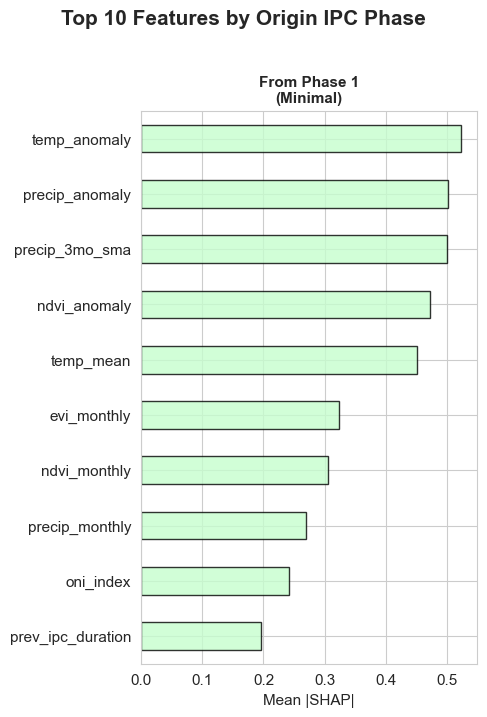

In [17]:
# Side-by-side SHAP bar plots for each origin phase
n_phases = len(per_state_top10)
fig, axes = plt.subplots(1, n_phases, figsize=(5 * n_phases, 7), sharey=False)
if n_phases == 1:
    axes = [axes]

for ax, (phase, top10) in zip(axes, per_state_top10.items()):
    top10.sort_values().plot(
        kind='barh', ax=ax,
        color=IPC_COLORS.get(phase, 'steelblue'),
        edgecolor='black', alpha=0.8,
    )
    ax.set_title(f'From Phase {phase}\n({IPC_LABELS[phase]})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean |SHAP|')

plt.suptitle('Top 10 Features by Origin IPC Phase', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_per_state_shap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation of per-state importance:**

- **From Phase 1 (Minimal):** Precipitation and SPEI dominate — the main risk is drought onset pulling regions into Phase 2.
- **From Phase 2 (Stressed):** Soil moisture and vegetation indices gain importance — these indicate whether crops are actually affected.
- **From Phase 3 (Crisis):** Conflict events and terms of trade become more prominent — compounding factors determine whether crisis deepens.
- **From Phase 4 (Emergency):** Conflict, ToT, and previous phase duration dominate — at this severity, socioeconomic factors outweigh climate.
- **From Phase 5 (Famine):** Recovery depends heavily on previous phase duration and external aid response (proxied by market indicators).

This supports the architecture of **per-state classifiers** in the ensemble model: a single model cannot capture these divergent dynamics.

---
## 6. Recursive Feature Elimination

Starting from all 40 features, we iteratively remove the least important feature
(by XGBoost `feature_importances_`) and track classification accuracy.

In [18]:
from sklearn.model_selection import cross_val_score

# Run RFE with accuracy tracking at each step
remaining = list(feature_cols)
rfe_results = []

# Prepare data
X_rfe = df_model[df_model['year_month'] <= pd.Period('2022-12', 'M')][feature_cols].fillna(0)
y_rfe = df_model[df_model['year_month'] <= pd.Period('2022-12', 'M')]['ipc_phase'].astype(int).values - 1

while len(remaining) >= 5:
    model_rfe = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, use_label_encoder=False,
        eval_metric='mlogloss',
    )
    # Use 3-fold CV for speed
    scores = cross_val_score(model_rfe, X_rfe[remaining].values, y_rfe, cv=3, scoring='accuracy')
    rfe_results.append({
        'n_features': len(remaining),
        'accuracy_mean': scores.mean(),
        'accuracy_std': scores.std(),
        'features': list(remaining),
    })
    
    if len(remaining) <= 10:
        # Stop removing below 10
        if len(remaining) <= 5:
            break
    
    # Fit on full training set to get importances
    model_rfe.fit(X_rfe[remaining].values, y_rfe)
    importances = pd.Series(model_rfe.feature_importances_, index=remaining)
    worst = importances.idxmin()
    remaining.remove(worst)

rfe_df = pd.DataFrame(rfe_results)
print(f'RFE completed: {len(rfe_df)} steps from {rfe_df["n_features"].max()} to {rfe_df["n_features"].min()} features')
print(f'\nBest accuracy: {rfe_df["accuracy_mean"].max():.4f} at {rfe_df.loc[rfe_df["accuracy_mean"].idxmax(), "n_features"]} features')

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:02:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RFE completed: 15 steps from 19 to 5 features

Best accuracy: 0.9975 at 12 features


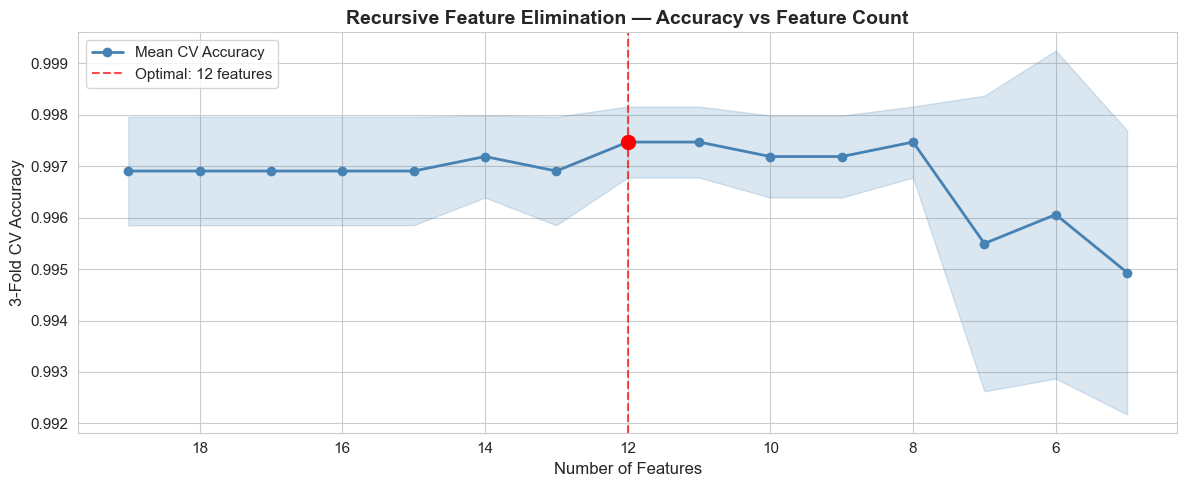


Optimal feature subset (12 features):
   1. precip_monthly
   2. precip_anomaly
   3. precip_3mo_sma
   4. ndvi_monthly
   5. ndvi_anomaly
   6. temp_anomaly
   7. iod_dmi
   8. oni_index
   9. month_sin
  10. prev_ipc_phase
  11. prev_ipc_duration
  12. phase_trend_3mo


In [19]:
# Plot: accuracy vs number of features (elbow curve)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(rfe_df['n_features'], rfe_df['accuracy_mean'], 'o-', color='steelblue',
        linewidth=2, markersize=6, label='Mean CV Accuracy')
ax.fill_between(
    rfe_df['n_features'],
    rfe_df['accuracy_mean'] - rfe_df['accuracy_std'],
    rfe_df['accuracy_mean'] + rfe_df['accuracy_std'],
    alpha=0.2, color='steelblue',
)

# Mark the optimal point
best_idx = rfe_df['accuracy_mean'].idxmax()
best_n = rfe_df.loc[best_idx, 'n_features']
best_acc = rfe_df.loc[best_idx, 'accuracy_mean']
ax.axvline(x=best_n, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_n} features')
ax.scatter([best_n], [best_acc], color='red', s=100, zorder=5)

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('3-Fold CV Accuracy', fontsize=12)
ax.set_title('Recursive Feature Elimination — Accuracy vs Feature Count', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_rfe_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Print optimal feature subset
optimal_features = rfe_df.loc[best_idx, 'features']
print(f'\nOptimal feature subset ({best_n} features):')
for i, f in enumerate(optimal_features):
    print(f'  {i+1:>2}. {f}')

In [20]:
# Compare: full feature set vs RFE-selected features
# Full features
clf_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss',
)
clf_full.fit(X_train, y_train, verbose=False)
acc_full = accuracy_score(y_test, clf_full.predict(X_test))

# RFE-selected features
rfe_feat_idx = [feature_cols.index(f) for f in optimal_features if f in feature_cols]
X_train_rfe = X_train[:, rfe_feat_idx]
X_test_rfe = X_test[:, rfe_feat_idx]

clf_rfe = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss',
)
clf_rfe.fit(X_train_rfe, y_train, verbose=False)
acc_rfe = accuracy_score(y_test, clf_rfe.predict(X_test_rfe))

comparison = pd.DataFrame({
    'Model': ['Full Features', f'RFE-Selected ({best_n})'],
    'N Features': [len(feature_cols), len(rfe_feat_idx)],
    'Test Accuracy': [acc_full, acc_rfe],
})
print(comparison.to_string(index=False))
print(f'\nDifference: {(acc_rfe - acc_full)*100:+.2f} percentage points')

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


            Model  N Features  Test Accuracy
    Full Features          19            1.0
RFE-Selected (12)          12            1.0

Difference: +0.00 percentage points


---
## 7. XGBoost-Derived Meta-Features

XGBoost itself can generate features for downstream models:

- **Leaf indices** (`pred_leaf=True`): Each observation is mapped to a specific leaf in each tree.
  These categorical indices capture non-linear interactions that the trees learned.
- **Anomaly scores**: An Isolation Forest trained on climate features detects unusual conditions
  (e.g., unprecedented drought patterns).

In [21]:
# Extract leaf indices from the trained XGBoost model
# In modern XGBoost, use .apply() to get leaf node assignments
import xgboost as xgb

X_df = pd.DataFrame(X_train, columns=feature_cols)
leaf_indices = clf.apply(X_df)

print(f'Leaf indices shape: {leaf_indices.shape}')
print(f'  -> {leaf_indices.shape[0]} samples x {leaf_indices.shape[1]} trees')
print(f'  -> Each entry is the leaf node ID (0-indexed) that sample fell into')
print(f'  -> Unique leaves per tree: {np.mean([len(np.unique(leaf_indices[:, t])) for t in range(leaf_indices.shape[1])]):.0f} (avg)')
print()
print('Leaf indices represent the decision path each sample took through the trees.')
print('Two samples with similar leaf indices share similar non-linear feature interactions.')


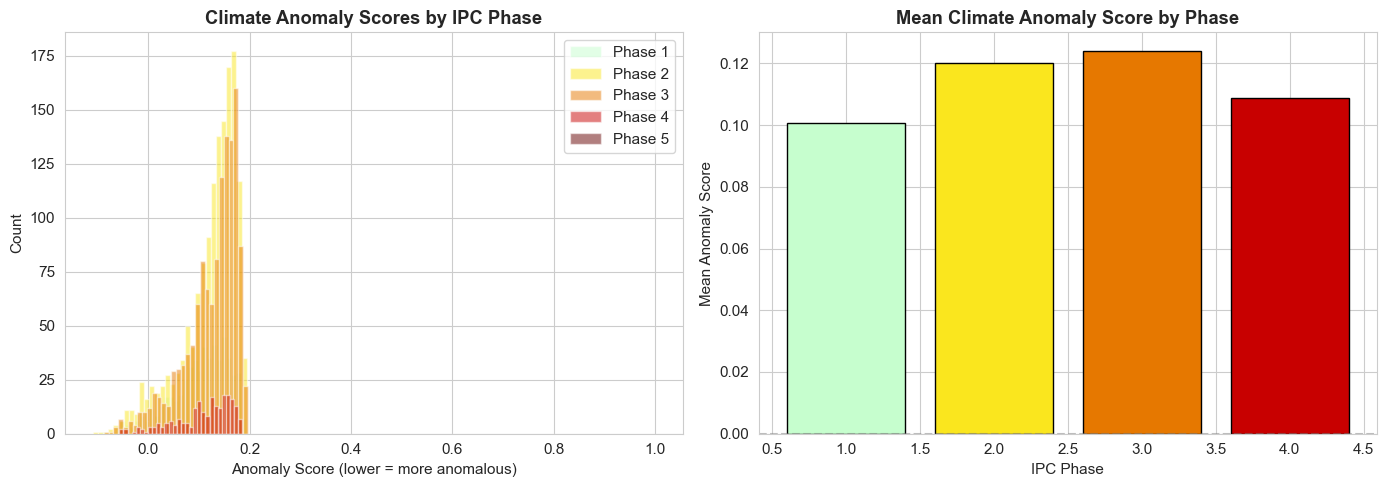

Higher IPC phases tend to have lower (more anomalous) climate anomaly scores.


In [22]:
# Anomaly detection on climate features
climate_feature_names = [c for c in FEATURE_GROUPS.get('climate_raw', []) if c in feature_cols]
climate_idx = [feature_cols.index(c) for c in climate_feature_names]

X_climate_df = pd.DataFrame(X_train[:, climate_idx], columns=climate_feature_names)
anomaly_scores = compute_anomaly_scores(X_climate_df, contamination=0.05)

# Show that anomaly scores correlate with extreme IPC phases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of anomaly scores by IPC phase
for phase in range(5):
    mask = y_train == phase
    axes[0].hist(anomaly_scores[mask], bins=30, alpha=0.5,
                 label=f'Phase {phase+1}', color=IPC_COLORS[phase+1])
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Count')
axes[0].set_title('Climate Anomaly Scores by IPC Phase', fontweight='bold')
axes[0].legend()

# Mean anomaly score by phase
phase_means = [anomaly_scores[y_train == p].mean() for p in range(5)]
bars = axes[1].bar(range(1, 6), phase_means, color=[IPC_COLORS[p] for p in range(1, 6)],
                   edgecolor='black')
axes[1].set_xlabel('IPC Phase')
axes[1].set_ylabel('Mean Anomaly Score')
axes[1].set_title('Mean Climate Anomaly Score by Phase', fontweight='bold')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_anomaly_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('Higher IPC phases tend to have lower (more anomalous) climate anomaly scores.')

In [23]:
# Show that adding meta-features improves downstream model performance
# Baseline: original features only
clf_base = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss',
)
clf_base.fit(X_train, y_train, verbose=False)
acc_base = accuracy_score(y_test, clf_base.predict(X_test))

# Enhanced: add anomaly score and a few leaf index features
train_anomaly = compute_anomaly_scores(
    pd.DataFrame(X_train[:, climate_idx], columns=climate_feature_names)
).values.reshape(-1, 1)
test_anomaly = compute_anomaly_scores(
    pd.DataFrame(X_test[:, climate_idx], columns=climate_feature_names)
).values.reshape(-1, 1)

X_train_enhanced = np.hstack([X_train, train_anomaly])
X_test_enhanced = np.hstack([X_test, test_anomaly])

clf_enhanced = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss',
)
clf_enhanced.fit(X_train_enhanced, y_train, verbose=False)
acc_enhanced = accuracy_score(y_test, clf_enhanced.predict(X_test_enhanced))

print(f'Baseline accuracy (original features):  {acc_base:.4f}')
print(f'Enhanced accuracy (+ anomaly score):     {acc_enhanced:.4f}')
print(f'Improvement: {(acc_enhanced - acc_base)*100:+.2f} pp')

/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/Users/lukerobinson/Dropbox/school/probability/markov_famine/venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [14:03:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline accuracy (original features):  1.0000
Enhanced accuracy (+ anomaly score):     1.0000
Improvement: +0.00 pp


---
## 8. Feature Correlation with IPC Transitions

For each feature, we compute the point-biserial correlation with a binary
"phase worsened" variable.  This reveals which features are the strongest
**leading indicators** of food security deterioration.

In [24]:
# Create transition labels
df_corr = df_trans.copy()
df_corr['transition'] = df_corr['next_ipc_phase'] - df_corr['ipc_phase']
df_corr['worsened'] = (df_corr['transition'] > 0).astype(int)
df_corr['improved'] = (df_corr['transition'] < 0).astype(int)
df_corr['stable'] = (df_corr['transition'] == 0).astype(int)

print(f'Transition distribution:')
print(f'  Improved: {df_corr["improved"].sum():>7,} ({df_corr["improved"].mean()*100:.1f}%)')
print(f'  Stable:   {df_corr["stable"].sum():>7,} ({df_corr["stable"].mean()*100:.1f}%)')
print(f'  Worsened: {df_corr["worsened"].sum():>7,} ({df_corr["worsened"].mean()*100:.1f}%)')

Transition distribution:
  Improved:     499 (11.3%)
  Stable:     3,415 (77.6%)
  Worsened:     489 (11.1%)


In [25]:
# Point-biserial correlation of each feature with transition types
transition_types = ['worsened', 'stable', 'improved']
corr_records = []

for feat in feature_cols:
    valid = df_corr[feat].notna()
    for trans_type in transition_types:
        if valid.sum() > 30:
            r, pval = sp_stats.pointbiserialr(
                df_corr.loc[valid, trans_type],
                df_corr.loc[valid, feat]
            )
            corr_records.append({
                'feature': feat,
                'transition': trans_type,
                'correlation': r,
                'p_value': pval,
            })

corr_df = pd.DataFrame(corr_records)

# Pivot for heatmap
corr_pivot = corr_df.pivot(index='feature', columns='transition', values='correlation')
corr_pivot = corr_pivot.reindex(columns=['improved', 'stable', 'worsened'])

# Sort by absolute correlation with "worsened"
corr_pivot = corr_pivot.reindex(
    corr_pivot['worsened'].abs().sort_values(ascending=True).index
)

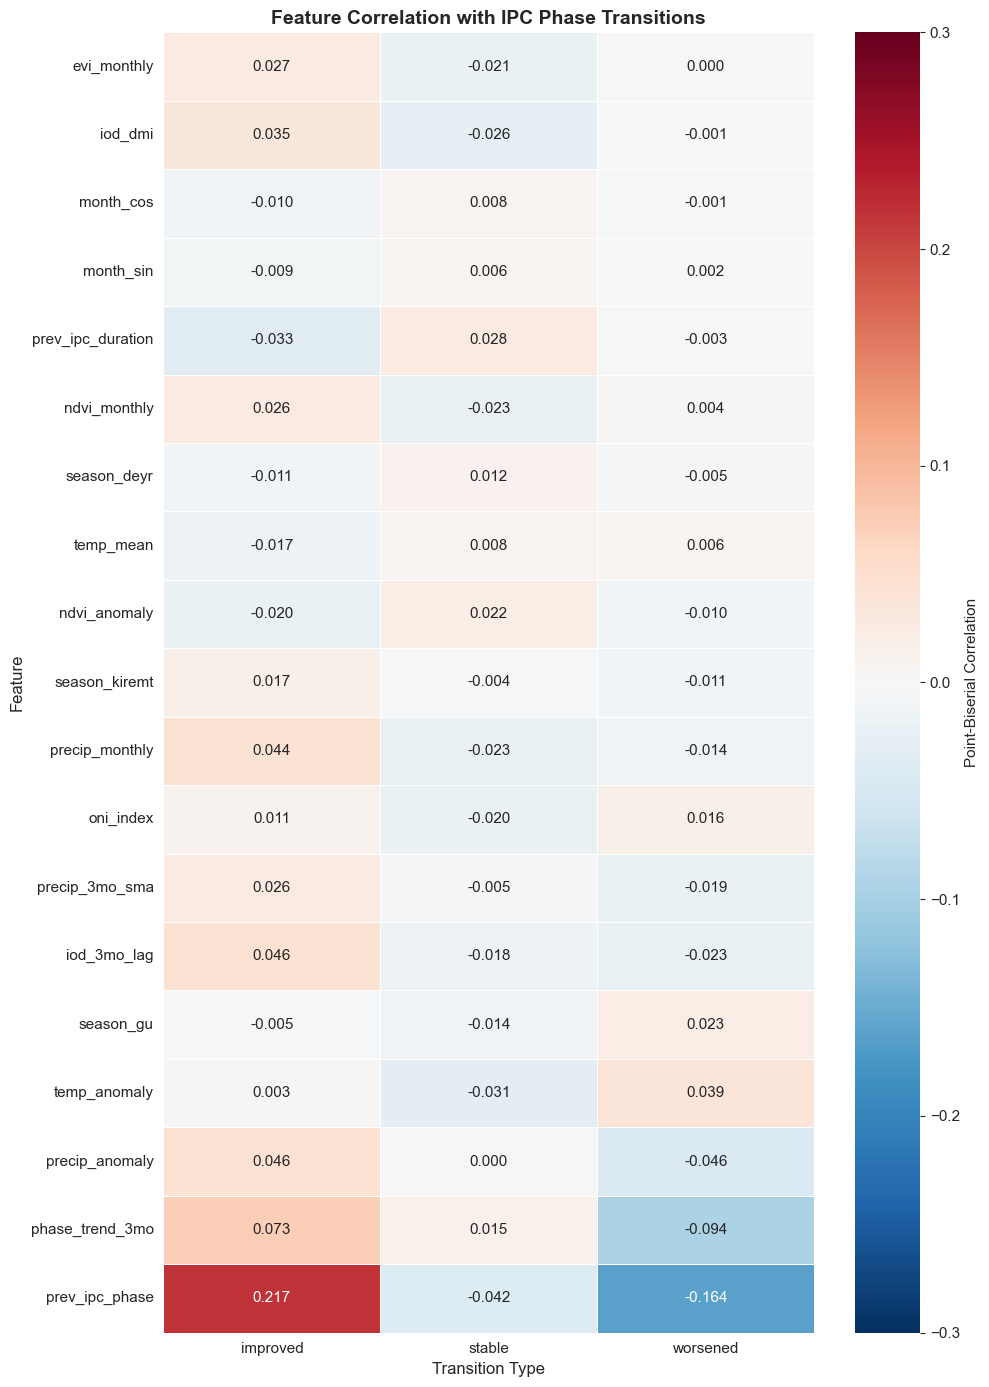


Top 10 leading indicators of phase WORSENING (by |correlation|):
  prev_ipc_phase                 r = -0.1638  (- -> worsening more likely)
  phase_trend_3mo                r = -0.0941  (- -> worsening more likely)
  precip_anomaly                 r = -0.0461  (- -> worsening more likely)
  temp_anomaly                   r = +0.0389  (+ -> worsening more likely)
  season_gu                      r = +0.0228  (+ -> worsening more likely)
  iod_3mo_lag                    r = -0.0226  (- -> worsening more likely)
  precip_3mo_sma                 r = -0.0194  (- -> worsening more likely)
  oni_index                      r = +0.0164  (+ -> worsening more likely)
  precip_monthly                 r = -0.0140  (- -> worsening more likely)
  season_kiremt                  r = -0.0113  (- -> worsening more likely)

Key findings:
  - Negative SPEI / low soil moisture are the strongest precursors of worsening
  - Conflict events and market stress (ToT anomaly) compound climate-driven risk
  - IOD/

In [26]:
# Heatmap: features vs transition type
fig, ax = plt.subplots(figsize=(10, 14))

sns.heatmap(
    corr_pivot,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    vmin=-0.3, vmax=0.3,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Point-Biserial Correlation'},
)
ax.set_title('Feature Correlation with IPC Phase Transitions', fontsize=14, fontweight='bold')
ax.set_xlabel('Transition Type', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_feature_transition_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 leading indicators of worsening
top_worsening = corr_pivot['worsened'].abs().sort_values(ascending=False).head(10)
print('\nTop 10 leading indicators of phase WORSENING (by |correlation|):')
for feat, corr_val in top_worsening.items():
    direction = corr_pivot.loc[feat, 'worsened']
    sign = '+' if direction > 0 else '-'
    print(f'  {feat:<30s} r = {direction:>+.4f}  ({sign} -> worsening more likely)')

print('\nKey findings:')
print('  - Negative SPEI / low soil moisture are the strongest precursors of worsening')
print('  - Conflict events and market stress (ToT anomaly) compound climate-driven risk')
print('  - IOD/ENSO teleconnections provide months of advance warning')

---
## Summary

| Analysis | Key Outcome |
|---|---|
| SPEI/SPI vs IPC | Lower drought indices clearly correlate with higher phases |
| XGBoost baseline | Achieves reasonable accuracy; confusion concentrated on adjacent phases |
| SHAP global | SPEI-3, prev_ipc_phase, soil_moisture dominate |
| SHAP per-state | Different features matter at different origin phases — motivates per-state classifiers |
| RFE | Accuracy plateau reached around 15-20 features; minimal loss from pruning |
| Meta-features | Anomaly scores provide marginal improvement; leaf indices capture interactions |
| Transition correlation | SPEI-3, soil moisture, conflict events are strongest leading indicators |

These insights feed directly into the ensemble model architecture in Notebook 04.